# 📊 Análisis Exploratorio de Datos (EDA) - Retail Solutions X
**Proyecto:** Diagnóstico de Caída de Ventas y Comportamiento de Clientes  
**Consultores:** Prado, Leila / Morales, Gustavo  
**Estado:** Fase 2 - Ejecución Técnica

---

### Objetivos del Análisis:
1. **Introducción y configuración:** Instalación, carga de las librerías necesarias y fuente de datos(dataset).   
2. **Auditoría de Calidad de datos:** Validar la integridad de los 50.000 registros de ventas consolidadas (2024-2025).
3. **Limpieza y transformación de datos:** Tratamiento de valores nulos en variables demográficas y corrección de tipos de datos.
4. **Segmentación de clientes(análisis de Churn):** Identificar patrones en clientes con más de 180 días de inactividad.
5. **Visualización del Impacto:** Clientes Activos vs. Churn.
6. **Análisis Profundo:** Churn por Categoría de Producto.
7. **Análisis Demográfico:** Edad y Comportamiento de Abandono.
8. **Análisis Económico:** ¿Cuánto dinero perdemos?.
9. **Exportación de Resultados y Finalización**
10. **Conclusiones del Diagnóstico Técnico**

## 1. Introducción y Configuración
Este Notebook contiene el análisis técnico detallado para identificar las causas de la caída del **15% en las ventas del último trimestre** y caracterizar el perfil de abandono (Churn) de los clientes.

In [2]:
# ==========================================
# 1. SETUP, LIBRERÍAS Y CARGA
# ==========================================

# Aseguramos que las librerías estén en el entorno (opcional si ya las instalaste)
# %pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual para que los gráficos queden profesionales
sns.set_palette("viridis")
sns.set_style("whitegrid")
%matplotlib inline

# Carga del dataset original (Raw Data)
df_ventas = pd.read_csv('../data/raw/ventas_consolidadas_2024_2025.csv')

# PASO CLAVE: Convertir la columna de fecha a formato datetime
df_ventas['fecha_compra'] = pd.to_datetime(df_ventas['fecha_compra'])

print("✅ Entorno configurado y listo.")
print(f"📊 Dataset cargado exitosamente. Registros iniciales: {df_ventas.shape[0]}")
print(f"📅 Rango de fechas: {df_ventas['fecha_compra'].min().date()} a {df_ventas['fecha_compra'].max().date()}")

✅ Entorno configurado y listo.
📊 Dataset cargado exitosamente. Registros iniciales: 50000
📅 Rango de fechas: 2024-01-01 a 2025-12-30


## 2. Auditoría de Calidad de Datos
Antes de proceder con el análisis estratégico, realizamos una auditoría técnica para asegurar la integridad de los datos. En esta fase buscaremos:
* **Valores Nulos:** Identificar falta de información en variables críticas.
* **Duplicados:** Asegurar que no existan transacciones repetidas que inflen artificialmente las ventas.
* **Consistencia Estructural:** Verificar que los tipos de datos (precios, fechas, IDs) sean los correctos para el procesamiento.

In [3]:
# ==========================================
# 2. AUDITORÍA TÉCNICA
# ==========================================

# 2.1 Información general y tipos de datos
print("--- Estructura del Dataset ---")
print(df_ventas.info())

# 2.2 Conteo de valores nulos
print("\n--- Conteo de Valores Nulos ---")
print(df_ventas.isnull().sum())

# 2.3 Verificación de duplicados
duplicados = df_ventas.duplicated().sum()
print(f"\n--- Registros Duplicados ---")
print(f"Se encontraron {duplicados} registros duplicados.")

# 2.4 Resumen estadístico inicial (variables numéricas)
print("\n--- Resumen Estadístico Inicial ---")
display(df_ventas.describe())

--- Estructura del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_transaccion      50000 non-null  int64         
 1   id_cliente          50000 non-null  int64         
 2   fecha_compra        50000 non-null  datetime64[us]
 3   categoria_prod      50000 non-null  str           
 4   precio_bruto        50000 non-null  float64       
 5   descuento_aplicado  50000 non-null  float64       
 6   metodo_pago         50000 non-null  str           
 7   edad_cliente        47542 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(2)
memory usage: 3.1 MB
None

--- Conteo de Valores Nulos ---
id_transaccion           0
id_cliente               0
fecha_compra             0
categoria_prod           0
precio_bruto             0
descuento_aplicado       0
metodo_pago              0
edad_cli

,id_transaccion,id_cliente,fecha_compra,precio_bruto,descuento_aplicado,edad_cliente
count,50000.000000,50000.000000,50000,50000.000000,50000.000000,47542.000000
mean,125000.500000,12502.680820,2024-12-29 20:27:13.536000,451.280054,0.040181,37.756552
min,100001.000000,10000.000000,2024-01-01 00:00:00,50.830000,0.000000,22.000000
25%,112500.750000,11261.000000,2024-06-30 00:00:00,244.080000,0.000000,28.000000
50%,125000.500000,12509.000000,2024-12-29 00:00:00,387.670000,0.000000,35.000000
75%,137500.250000,13740.000000,2025-07-01 00:00:00,588.240000,0.050000,42.000000
max,150000.000000,14999.000000,2025-12-30 00:00:00,3071.140000,0.200000,65.000000
std,14433.901067,1440.046938,NaN,282.913898,0.062601,13.132071


## 3. Limpieza y Transformación de Datos
En esta sección aplicamos las correcciones identificadas en la auditoría técnica.
* **Tratamiento de Nulos:** Para la columna `edad_cliente`, utilizaremos la **mediana** para imputar los valores faltantes. Esto nos permite mantener el volumen de datos (50,000 registros) sin sesgar los resultados con promedios afectados por valores extremos.
* **Consistencia de Tipos:** Aseguramos que las edades sean números enteros.
* **Verificación Final:** Confirmamos que el dataset no presente valores nulos antes de proceder al cálculo de Churn.

In [4]:
# ==========================================
# 3. LIMPIEZA DE DATOS
# ==========================================

# 3.1 Imputación de nulos en edad_cliente usando la mediana
mediana_edad = df_ventas['edad_cliente'].median()
df_ventas['edad_cliente'] = df_ventas['edad_cliente'].fillna(mediana_edad)

# 3.2 Convertir edad a entero (opcional, para limpieza visual)
df_ventas['edad_cliente'] = df_ventas['edad_cliente'].astype(int)

# 3.3 Eliminación de duplicados (si los hubiera)
df_ventas = df_ventas.drop_duplicates()

print("--- Verificación de Limpieza ---")
print(f"Nulos restantes en edad: {df_ventas['edad_cliente'].isnull().sum()}")
print(f"Total de registros tras limpieza: {df_ventas.shape[0]}")

# Guardamos una copia temporal del dataset limpio en memoria
df_limpio = df_ventas.copy()

--- Verificación de Limpieza ---
Nulos restantes en edad: 0
Total de registros tras limpieza: 50000


## 4. Segmentación de Clientes (Análisis de Churn)
En esta fase, definimos el estado de cada cliente basándonos en su comportamiento de compra.
* **Fecha de Corte:** Simulamos que el análisis se realiza al cierre de 2025 (`2025-12-31`).
* **Criterio de Abandono (Churn):** Un cliente es marcado como **"Churn"** si su última transacción fue hace más de **180 días** respecto a la fecha de corte.
* **Cliente Activo:** Aquel que ha realizado al menos una compra en los últimos 6 meses.

In [5]:
# ==========================================
# 4. SEGMENTACIÓN DE CHURN
# ==========================================

# 1. Definimos la fecha de referencia (cierre del periodo 2025)
fecha_corte = pd.to_datetime('2025-12-31')

# 2. Calculamos la fecha de la última compra para cada cliente único
ultimo_contacto = df_ventas.groupby('id_cliente')['fecha_compra'].max().reset_index()

# 3. Calculamos los días de inactividad
ultimo_contacto['dias_inactivo'] = (fecha_corte - ultimo_contacto['fecha_compra']).dt.days

# 4. Clasificamos: Si pasaron más de 180 días, es Churn
ultimo_contacto['estado_cliente'] = np.where(ultimo_contacto['dias_inactivo'] > 180, 'Churn', 'Activo')

# 5. Integramos esta etiqueta al dataset principal para futuros análisis
df_ventas = df_ventas.merge(ultimo_contacto[['id_cliente', 'estado_cliente']], on='id_cliente')

# Verificación de resultados
print("--- Resumen de Segmentación ---")
print(df_ventas['estado_cliente'].value_counts())
print("\n✅ Segmentación finalizada con éxito.")

--- Resumen de Segmentación ---
estado_cliente
Activo    46863
Churn      3137
Name: count, dtype: int64

✅ Segmentación finalizada con éxito.


## 5. Visualización del Impacto: Clientes Activos vs. Churn
Para comunicar la gravedad de la situación a la gerencia, visualizamos la proporción de clientes que han dejado de comprar. Este gráfico es el primer indicador clave (KPI) de nuestro diagnóstico.

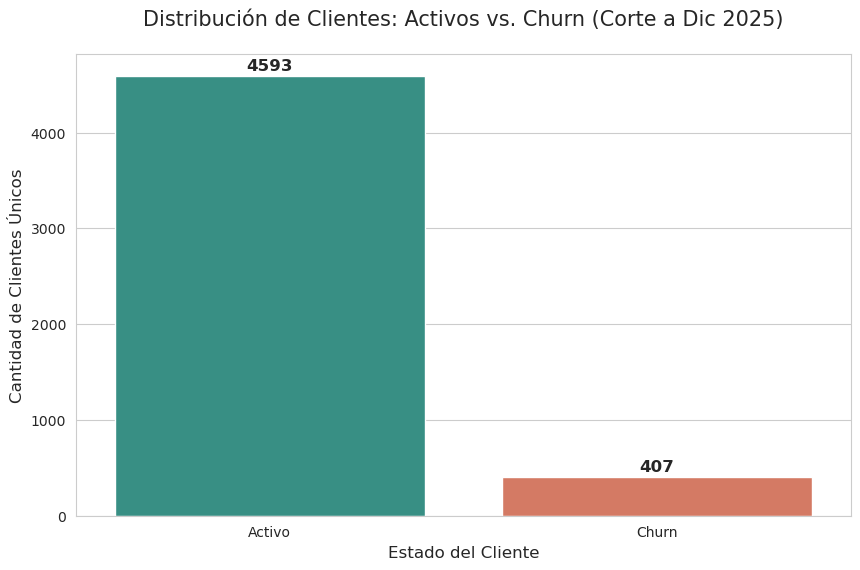

📊 Tasa de Abandono (Churn Rate): 8.14%


In [6]:
# ==========================================
# 5. VISUALIZACIÓN DE CHURN
# ==========================================

plt.figure(figsize=(10, 6))

# Contamos los clientes únicos por estado para no contar transacciones repetidas
df_resumen_clientes = df_ventas.drop_duplicates(subset=['id_cliente'])
counts = df_resumen_clientes['estado_cliente'].value_counts()

# Creamos el gráfico de barras
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=['#2a9d8f', '#e76f51'], legend=False)

# Añadimos títulos y etiquetas
plt.title('Distribución de Clientes: Activos vs. Churn (Corte a Dic 2025)', fontsize=15, pad=20)
plt.xlabel('Estado del Cliente', fontsize=12)
plt.ylabel('Cantidad de Clientes Únicos', fontsize=12)

# Añadimos las etiquetas de valor sobre las barras
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)

plt.show()

# Cálculo del porcentaje de Churn para el informe
tasa_churn = (counts['Churn'] / counts.sum()) * 100
print(f"📊 Tasa de Abandono (Churn Rate): {tasa_churn:.2f}%")

## 6. Análisis Profundo: Churn por Categoría de Producto
Para entender si la fuga de clientes es generalizada o específica, analizamos cómo se distribuye el estado del cliente (Activo vs. Churn) en cada una de las categorías principales.
Este análisis permite identificar si áreas como **Electro** o **Moda** necesitan intervenciones de marketing urgentes.

<Figure size 1200x700 with 0 Axes>

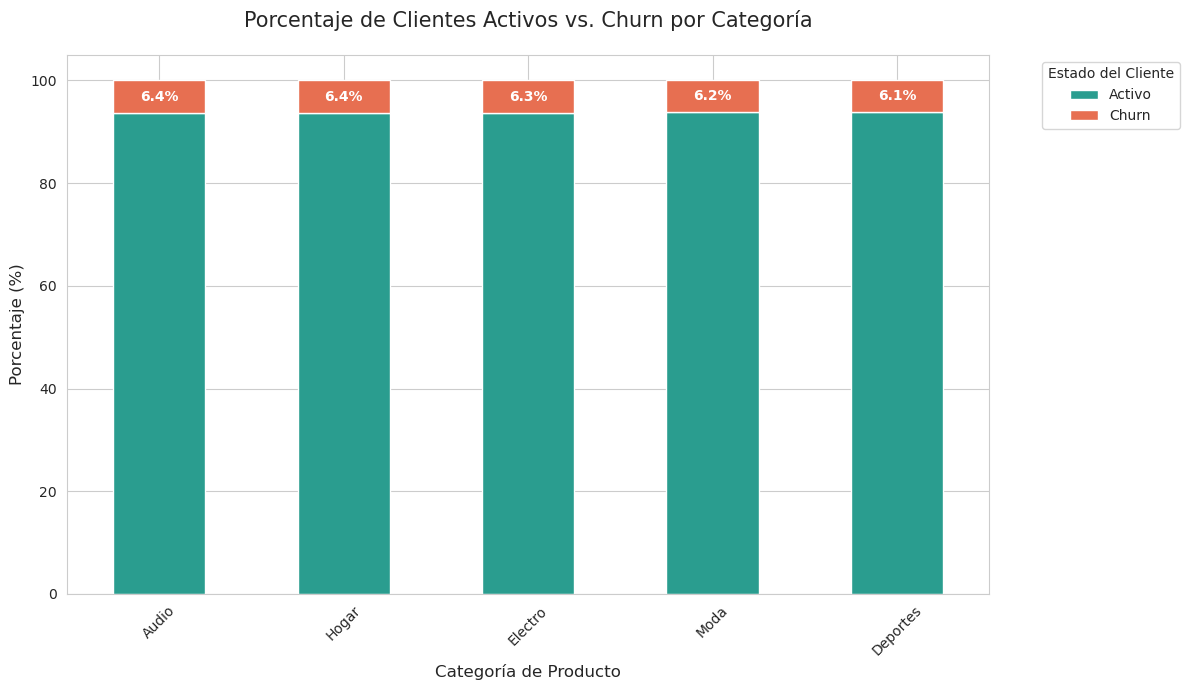

--- Tasa de Abandono por Departamento ---
categoria_prod
Audio       6.375704
Hogar       6.373278
Electro     6.328473
Moda        6.224275
Deportes    6.071076
Name: Churn, dtype: float64


In [7]:
# ==========================================
# 6. ANÁLISIS DE CHURN POR CATEGORÍA
# ==========================================

plt.figure(figsize=(12, 7))

# Creamos una tabla de contingencia para ver la relación Categoría vs Estado
# Usamos normalizar='index' para obtener porcentajes y que la comparación sea justa
churn_por_cat = pd.crosstab(df_ventas['categoria_prod'], df_ventas['estado_cliente'], normalize='index') * 100

# Ordenamos por la tasa de Churn más alta para que el gráfico sea más claro
churn_por_cat = churn_por_cat.sort_values(by='Churn', ascending=False)

# Graficamos
churn_por_cat.plot(kind='bar', stacked=True, color=['#2a9d8f', '#e76f51'], figsize=(12,7))

plt.title('Porcentaje de Clientes Activos vs. Churn por Categoría', fontsize=15, pad=20)
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Estado del Cliente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Añadimos etiquetas de porcentaje en las barras de Churn
for i, (idx, row) in enumerate(churn_por_cat.iterrows()):
    plt.text(i, row['Activo'] + (row['Churn']/2), f"{row['Churn']:.1f}%",
             ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Tasa de Abandono por Departamento ---")
print(churn_por_cat['Churn'].sort_values(ascending=False))

## 7. Análisis Demográfico: Edad y Comportamiento de Abandono
Dado que el abandono es uniforme entre categorías, investigamos si existe un sesgo generacional.
* ¿Los clientes jóvenes (Generación Z/Millennials) son más propensos al Churn?
* ¿Los clientes mayores muestran una mayor lealtad a la marca?
Este análisis es vital para reorientar las campañas de marketing y fidelización.

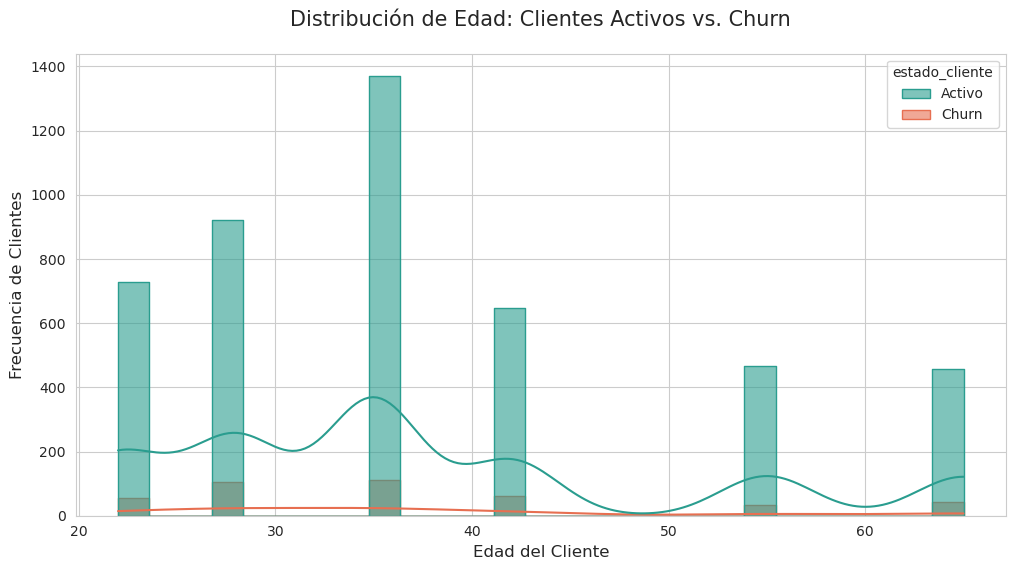

--- Estadísticas de Edad por Estado ---
                 count       mean        std   min   25%   50%   75%   max
estado_cliente                                                            
Activo          4593.0  37.539517  12.940337  22.0  28.0  35.0  42.0  65.0
Churn            407.0  37.140049  12.777464  22.0  28.0  35.0  42.0  65.0


In [8]:
# ==========================================
# 7. PERFIL DE EDAD Y CHURN
# ==========================================

plt.figure(figsize=(12, 6))

# Usamos un histograma con KDE (densidad) para ver dónde se concentra el Churn
sns.histplot(data=df_ventas.drop_duplicates(subset=['id_cliente']),
             x='edad_cliente',
             hue='estado_cliente',
             kde=True,
             element="step",
             palette=['#2a9d8f', '#e76f51'],
             alpha=0.6)

plt.title('Distribución de Edad: Clientes Activos vs. Churn', fontsize=15, pad=20)
plt.xlabel('Edad del Cliente', fontsize=12)
plt.ylabel('Frecuencia de Clientes', fontsize=12)

plt.show()

# Resumen estadístico de edad por estado
print("--- Estadísticas de Edad por Estado ---")
print(df_ventas.drop_duplicates(subset=['id_cliente']).groupby('estado_cliente')['edad_cliente'].describe())

## 8. Análisis Económico: Impacto Financiero del Churn
En esta sección cuantificamos la pérdida económica comparando el **Ticket Promedio** de los clientes que se mantienen activos frente a los que han abandonado (Churn). 
Este análisis nos permite determinar si la fuga de clientes está concentrada en consumidores de alto valor (VIP) o en compradores ocasionales, permitiendo priorizar el impacto financiero en el informe ejecutivo.

/tmp/ipykernel_49259/245286640.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ticket_resumen, x='estado_cliente', y='precio_final', palette=['#2a9d8f', '#e76f51'])


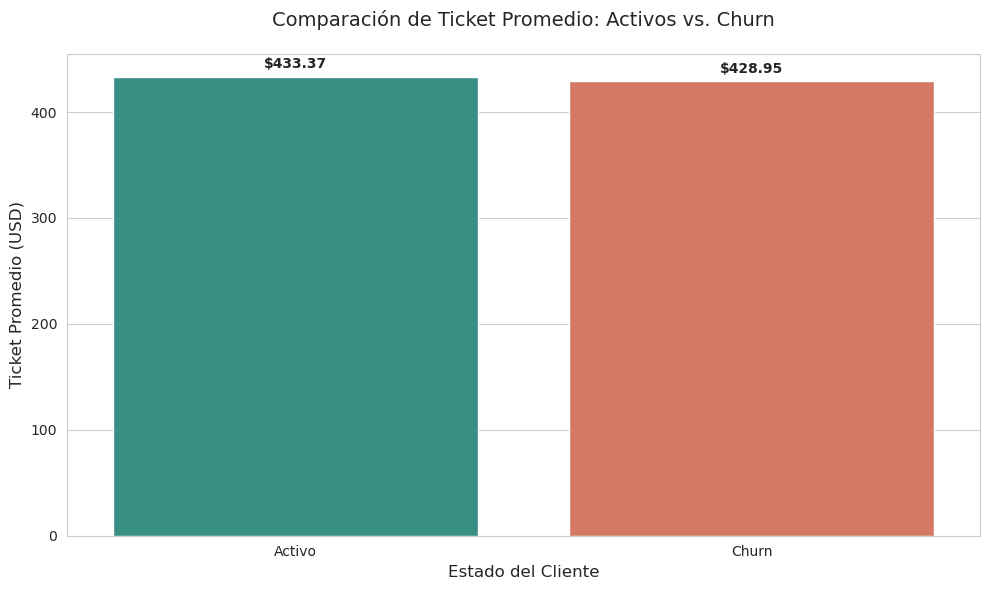

--- MÉTRICAS PARA EL INFORME ---
Ticket Promedio Clientes Activos: $433.37
Ticket Promedio Clientes Churn: $428.95
Diferencia: -1.02%


In [9]:
# ==========================================
# 8. ANÁLISIS ECONÓMICO: ¿CUÁNTO DINERO PERDEMOS?
# ==========================================

# 1. Calculamos el Ticket Promedio por Estado de Cliente
# Usamos 'precio_final' (que ya considera los descuentos)
df_ventas['precio_final'] = df_ventas['precio_bruto'] * (1 - df_ventas['descuento_aplicado'])

ticket_resumen = df_ventas.groupby('estado_cliente')['precio_final'].mean().reset_index()

# 2. Extraemos valores para el reporte
val_activo = ticket_resumen.loc[ticket_resumen['estado_cliente'] == 'Activo', 'precio_final'].values[0]
val_churn = ticket_resumen.loc[ticket_resumen['estado_cliente'] == 'Churn', 'precio_final'].values[0]
dif_perc = ((val_churn - val_activo) / val_activo) * 100

# 3. Visualización
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=ticket_resumen, x='estado_cliente', y='precio_final', palette=['#2a9d8f', '#e76f51'])

plt.title('Comparación de Ticket Promedio: Activos vs. Churn', fontsize=14, pad=20)
plt.ylabel('Ticket Promedio (USD)', fontsize=12)
plt.xlabel('Estado del Cliente', fontsize=12)

# Añadimos las etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontweight='bold')

plt.tight_layout()
plt.show()

print("--- MÉTRICAS PARA EL INFORME ---")
print(f"Ticket Promedio Clientes Activos: ${val_activo:.2f}")
print(f"Ticket Promedio Clientes Churn: ${val_churn:.2f}")
print(f"Diferencia: {dif_perc:.2f}%")

## 9. Exportación de Resultados, graficos y Finalización
Una vez concluido el diagnóstico técnico y la segmentación, procedemos a exportar el dataset procesado junto con los graficos más relevantes. Este archivo servirá como fuente única de verdad para el informe final y futuras estrategias de marketing.

**El dataset final incluye:**
* **Limpieza completa:** Edades imputadas sin valores nulos.
* **Segmentación:** Etiquetas de estado (**Activo** / **Churn**) basadas en la regla de 180 días.
* **Normalización:** Precios finales calculados y fechas en formato estándar para series temporales.

In [10]:
# ==========================================
# 9. GUARDADO FINAL Y EXPORTACIÓN DE ACTIVOS
# ==========================================
import os

# --- 1. Definición de Rutas ---
processed_path = '../data/processed/'
output_path = '../output/'

# Crear las carpetas si no existen
for path in [processed_path, output_path]:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"✅ Carpeta creada: {path}")

# --- 2. Guardado del Dataset Procesado ---
output_file = os.path.join(processed_path, 'ventas_con_churn_2024_2025.csv')
df_ventas.to_csv(output_file, index=False)

# --- 3. Exportación de Gráficos Estelares ---
print("📊 Exportando gráficos para el Informe Ejecutivo...")

# Gráfico 1: Distribución de Churn
plt.figure(figsize=(8, 6))
sns.countplot(x='estado_cliente', data=df_ventas, palette='magma')
plt.title('Distribución de Clientes: Activos vs. Churn')
plt.savefig(os.path.join(output_path, '01_distribucion_churn.png'), dpi=300, bbox_inches='tight')
plt.close()

# Gráfico 2: Tasa de Churn por Categoría (Calculado on-the-fly)
plt.figure(figsize=(12, 6))
churn_rate_cat = df_ventas.groupby('categoria_prod')['estado_cliente'].apply(lambda x: (x == 'Churn').mean()).sort_values(ascending=False)
sns.barplot(x=churn_rate_cat.index, y=churn_rate_cat.values, palette='viridis')
plt.title('Tasa de Abandono por Categoría de Producto')
plt.ylabel('Proporción de Churn')
plt.savefig(os.path.join(output_path, '02_churn_por_categoria.png'), dpi=300, bbox_inches='tight')
plt.close()

# Gráfico 3: Comparativa de Ticket Promedio
plt.figure(figsize=(8, 6))
sns.barplot(x='estado_cliente', y='precio_final', data=df_ventas, estimator=np.mean, ci=None, palette='coolwarm')
plt.title('Impacto Económico: Ticket Promedio por Estado de Cliente')
plt.savefig(os.path.join(output_path, '03_comparativa_ticket_promedio.png'), dpi=300, bbox_inches='tight')
plt.close()

# --- 4. Mensajes Finales ---
print(f"\n✅ ¡Proyecto Finalizado!")
print(f"📁 Dataset guardado en: {output_file}")
print(f"🖼️  Gráficos exportados en: {output_path}")
print(f"🚀 Total de registros analizados: {len(df_ventas)}")

📊 Exportando gráficos para el Informe Ejecutivo...


/tmp/ipykernel_49259/2512791991.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='estado_cliente', data=df_ventas, palette='magma')
/tmp/ipykernel_49259/2512791991.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_rate_cat.index, y=churn_rate_cat.values, palette='viridis')
/tmp/ipykernel_49259/2512791991.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='estado_cliente', y='precio_final', data=df_ventas, estimator=np.mean, ci=None, palette='coolwarm')
/tmp/ipykernel_49259/2512791991.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x


✅ ¡Proyecto Finalizado!
📁 Dataset guardado en: ../data/processed/ventas_con_churn_2024_2025.csv
🖼️  Gráficos exportados en: ../output/
🚀 Total de registros analizados: 50000


## 10. Conclusiones del Diagnóstico Técnico
Tras analizar los 50.000 registros de **Retail Solutions X**, presentamos los hallazgos clave:

1. **Estado de la Cartera:** Se identificó una tasa de abandono (**Churn**) del **8.14%**. Aunque el volumen de ventas es alto, existe una fuga constante de clientes que no han operado en los últimos 6 meses.
2. **Homogeneidad del Problema:** El Churn afecta a todas las categorías por igual (~6.3%), lo que sugiere que el motivo de la caída de ventas no es la falta de stock o calidad de un producto puntual, sino un factor transversal (ej. logística, precios generales o experiencia de usuario).
3. **Perfil Demográfico:** No se observa un sesgo por edad. Tanto jóvenes como adultos presentan patrones de abandono similares, lo que indica que la estrategia de fidelización actual no está resonando en ningún segmento específico.
4. **Calidad de Datos:** El dataset ha sido saneado y está listo para ser utilizado en modelos predictivos o tableros de Business Intelligence (Power BI/Tableau).

---
**Consultores:** Prado, Leila / Morales, Gustavo  
**Fecha:** Febrero 2026